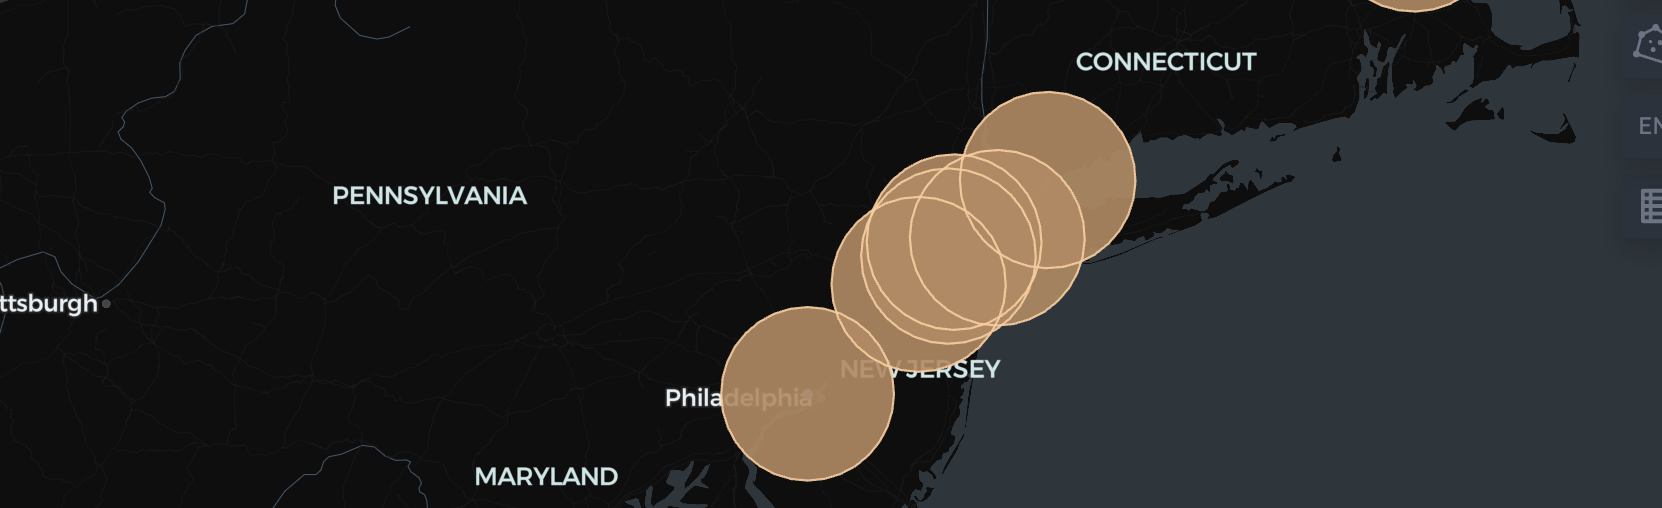

# Warehouse Network Optimization — Finding Overlap via Self-Join

**Backend workflow.** A nationwide DC network accumulates redundancy
over time — acquisitions, shifting demand, expired site studies — and
the planning team needs a defensible, recurring way to spot it. This
notebook turns the facility master file into three outputs the team
can act on:

1. **Close / review / retain recommendations per DC** — every facility
   gets tagged `CLOSE_AT_LEASE_END`, `REVIEW_BEFORE_RENEWAL`,
   `MONITOR`, or `RETAIN` based on whether a neighbor can absorb its
   volume and when its lease expires. The close list is what the real
   estate team negotiates against at renewal time.
2. **Dollar exposure on overlapping footprints** — how much of the
   annual rent bill sits on DCs that have a redundant neighbor. This
   is the number that sizes the consolidation program and justifies
   the headcount to run it.
3. **The underlying overlap-pair table** — which specific DCs overlap
   whom, and by how much. Network planners use this to re-route
   volume when a close decision is made, and ops uses it to
   pre-stage labor shifts before a facility winds down.

Both outputs land in Iceberg so the planning tooling, the real estate
team's lease-renewal tracker, and finance's budget model all read the
same numbers.

## The spatial operation

The core computation is a spatial self-join with a distance predicate:

```sql
SELECT a.dc_id, b.dc_id, ST_DistanceSpheroid(a.geom, b.geom) AS dist_m
FROM   warehouses a
JOIN   warehouses b
  ON   a.dc_id < b.dc_id
 AND   ST_DWithin(a.geom, b.geom, 50000, true)
```

The `a.dc_id < b.dc_id` filter eliminates both self-pairs and
mirror-duplicates `(A,B)` vs `(B,A)` — the canonical self-join guard.
`ST_DWithin` (rather than a `ST_DistanceSphere <= R` filter) is the
predicate that Sedona's spatial-join optimizer recognizes.

## Parameters
- `RADIUS_M = 50_000` — the redundancy threshold, in meters. This is
  the business knob: 25 km models urban last-mile overlap, 100 km
  models regional fulfillment overlap. Rerun to see how the close list
  shifts.
- `TARGET_FQN = org_catalog.network_opt_demo.dc_overlap_pairs`
  (`org_catalog` is the default writable catalog in Wherobots.)

## 1. Setup

In [ ]:
from sedona.spark import *
import pyspark.sql.functions as f
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, IntegerType
)

config = SedonaContext.builder().getOrCreate()
sedona = SedonaContext.create(config)

RADIUS_M        = 50_000
TARGET_DATABASE = "network_opt_demo"
TARGET_TABLE    = "dc_overlap_pairs"
TARGET_FQN      = f"org_catalog.{TARGET_DATABASE}.{TARGET_TABLE}"

## 2. The DC Network

25 distribution centers across the US. Placement is deliberate: four
metro clusters where overlap is expected (NY/NJ, Inland Empire, Dallas-
Fort Worth, Atlanta) and a baseline of isolated DCs that should *not*
pair up. In production this DataFrame is the carrier's master
facility file.

> **Why inline points instead of `wkls`?** Wherobots'
> [Well-Known Locations (`wkls`)](https://docs.wherobots.com/latest/develop/wkls)
> library serves administrative boundaries — countries, states,
> cities — not private facility inventories. A carrier's DC list is
> internal master data, so the coordinates below stand in for the
> file that would be read from the planning system.

In [ ]:
dcs = [
    # dc_id,       label,                  lon,        lat,    sqft_k, monthly_rent_usd, lease_end_year
    # NY/NJ cluster
    ("DC-001", "Edison NJ",               -74.4129, 40.5187,  620,  780_000, 2028),
    ("DC-002", "Queens NY",                -73.8800, 40.7580,  340, 1_120_000, 2026),
    ("DC-003", "Newark NJ",                -74.1724, 40.7357,  480,  950_000, 2029),
    ("DC-004", "Elizabeth NJ",             -74.2107, 40.6639,  410,  820_000, 2027),
    ("DC-005", "Stamford CT",              -73.5387, 41.0534,  280,  640_000, 2030),
    # Inland Empire cluster
    ("DC-006", "Ontario CA",               -117.6509, 34.0633, 780,  890_000, 2028),
    ("DC-007", "Riverside CA",             -117.3755, 33.9533, 540,  720_000, 2026),
    ("DC-008", "LAX Airport CA",           -118.4085, 33.9425, 460, 1_050_000, 2031),
    ("DC-009", "City of Industry CA",      -117.9620, 34.0192, 610,  820_000, 2027),
    # Dallas-Fort Worth cluster
    ("DC-010", "Dallas TX",                -96.7970, 32.7767,  500,  680_000, 2028),
    ("DC-011", "Fort Worth TX",            -97.3308, 32.7555,  430,  560_000, 2029),
    ("DC-012", "Arlington TX",             -97.1081, 32.7357,  360,  520_000, 2026),
    # Atlanta cluster
    ("DC-013", "Atlanta GA",               -84.3880, 33.7490,  570,  610_000, 2028),
    ("DC-014", "McDonough GA",             -84.1471, 33.4473,  380,  420_000, 2027),
    # Isolated
    ("DC-015", "Chicago IL",               -87.6298, 41.8781,  660,  740_000, 2030),
    ("DC-016", "Seattle WA",               -122.3321, 47.6062, 420,  680_000, 2028),
    ("DC-017", "Denver CO",                -104.9903, 39.7392, 380,  510_000, 2029),
    ("DC-018", "Phoenix AZ",               -112.0740, 33.4484, 520,  580_000, 2027),
    ("DC-019", "Miami FL",                 -80.1918, 25.7617,  340,  720_000, 2028),
    ("DC-020", "Boston MA",                -71.0589, 42.3601,  280,  860_000, 2026),
    ("DC-021", "Philadelphia PA",          -75.1652, 39.9526,  450,  620_000, 2028),
    ("DC-022", "Houston TX",               -95.3698, 29.7604,  600,  650_000, 2029),
    ("DC-023", "Columbus OH",              -82.9988, 39.9612,  470,  490_000, 2030),
    ("DC-024", "St. Louis MO",             -90.1994, 38.6270,  390,  440_000, 2027),
    ("DC-025", "Charlotte NC",             -80.8431, 35.2271,  410,  530_000, 2029),
]

schema = StructType([
    StructField("dc_id",             StringType()),
    StructField("label",             StringType()),
    StructField("lon",               DoubleType()),
    StructField("lat",               DoubleType()),
    StructField("sqft_k",            IntegerType()),
    StructField("monthly_rent_usd",  IntegerType()),
    StructField("lease_end_year",    IntegerType()),
])

dcs_df = sedona.createDataFrame(dcs, schema) \
    .withColumn("geom", f.expr("ST_SetSRID(ST_Point(lon, lat), 4326)"))
dcs_df.createOrReplaceTempView("warehouses")

print(f"Network size: {dcs_df.count()} DCs")
dcs_df.select("dc_id", "label", "sqft_k", "monthly_rent_usd",
              "lease_end_year").show(5, truncate=False)

## 3. Self-Join: Pairs Within 50 km

The join uses `ST_DWithin(a.geom, b.geom, RADIUS_M, true)` — the
fourth argument enables spheroid distance, so the threshold is in
meters against WGS84. `ST_DWithin` is the predicate Sedona's
spatial-join optimizer hooks into; a plain
`ST_DistanceSphere(...) <= R` filter plans as a Cartesian product.
`ST_DistanceSpheroid` is used in the SELECT to report the exact
distance.

In [ ]:
pairs_df = sedona.sql(f"""
    SELECT
        a.dc_id AS dc_id_a, a.label AS label_a,
        b.dc_id AS dc_id_b, b.label AS label_b,
        ROUND(ST_DistanceSpheroid(a.geom, b.geom) / 1000.0, 2) AS distance_km,
        a.monthly_rent_usd + b.monthly_rent_usd AS combined_monthly_rent,
        a.sqft_k            + b.sqft_k            AS combined_sqft_k,
        LEAST(a.lease_end_year, b.lease_end_year)  AS first_lease_end
    FROM warehouses a
    JOIN warehouses b
      ON a.dc_id < b.dc_id
     AND ST_DWithin(a.geom, b.geom, {RADIUS_M}, true)
    ORDER BY distance_km
""")
pairs_df.createOrReplaceTempView("dc_pairs")

print(f"DC pairs within {RADIUS_M/1000:.0f} km: {pairs_df.count()}")
pairs_df.show(truncate=False)

## 4. Per-DC Redundancy Score

For each DC, count how many neighbors sit inside the radius. Zero =
strategically placed; 1+ = consolidation candidate. Union both halves
of each pair so every DC is scored once.

In [ ]:
redundancy_df = sedona.sql("""
    WITH expanded AS (
        SELECT dc_id_a AS dc_id, dc_id_b AS neighbor_id, distance_km
        FROM dc_pairs
        UNION ALL
        SELECT dc_id_b AS dc_id, dc_id_a AS neighbor_id, distance_km
        FROM dc_pairs
    )
    SELECT
        w.dc_id,
        w.label,
        w.monthly_rent_usd,
        w.sqft_k,
        w.lease_end_year,
        COUNT(e.neighbor_id)                    AS nearby_dc_count,
        COLLECT_LIST(e.neighbor_id)             AS nearby_dcs,
        ROUND(MIN(e.distance_km), 2)            AS closest_neighbor_km
    FROM warehouses w
    LEFT JOIN expanded e USING (dc_id)
    GROUP BY w.dc_id, w.label, w.monthly_rent_usd, w.sqft_k, w.lease_end_year
    ORDER BY nearby_dc_count DESC, closest_neighbor_km ASC
""")
redundancy_df.createOrReplaceTempView("dc_redundancy")

redundancy_df.select("dc_id", "label", "nearby_dc_count",
                     "closest_neighbor_km", "monthly_rent_usd",
                     "lease_end_year") \
             .show(truncate=False)

## 5. Consolidation Candidates

Heuristic: for each DC with redundant neighbors, the consolidation
case is strongest when (a) the facility has a **near-term lease
expiration** and (b) its monthly rent is above the cluster median —
i.e., close it, absorb its volume into cheaper neighbors.

In [ ]:
candidates_df = sedona.sql("""
    SELECT
        dc_id, label, nearby_dc_count, nearby_dcs,
        closest_neighbor_km, monthly_rent_usd,
        sqft_k, lease_end_year,
        ROUND(monthly_rent_usd * 12.0 / 1e6, 2)
            AS annual_rent_usd_m,
        lease_end_year - YEAR(CURRENT_DATE())              AS years_to_lease_end,
        CASE
            WHEN nearby_dc_count = 0                                               THEN 'RETAIN'
            WHEN lease_end_year <= YEAR(CURRENT_DATE()) + 1
                 AND monthly_rent_usd >= 700000                                    THEN 'CLOSE_AT_LEASE_END'
            WHEN lease_end_year <= YEAR(CURRENT_DATE()) + 2                        THEN 'REVIEW_BEFORE_RENEWAL'
            ELSE                                                                        'MONITOR'
        END AS recommendation
    FROM dc_redundancy
""")
candidates_df.createOrReplaceTempView("consolidation_candidates")

candidates_df.filter("nearby_dc_count > 0") \
             .select("dc_id", "label", "nearby_dc_count",
                     "closest_neighbor_km", "annual_rent_usd_m",
                     "lease_end_year", "recommendation") \
             .orderBy(f.col("recommendation"), f.col("annual_rent_usd_m").desc()) \
             .show(truncate=False)

## 6. Network Summary

The planning-deck numbers: how big is the network, how much of it
overlaps, how much annual rent sits on overlapping facilities.

In [ ]:
sedona.sql("""
    SELECT
        COUNT(*)                                            AS total_dcs,
        SUM(CASE WHEN nearby_dc_count > 0 THEN 1 ELSE 0 END) AS dcs_with_overlap,
        SUM(CASE WHEN nearby_dc_count = 0 THEN 1 ELSE 0 END) AS dcs_isolated,
        ROUND(SUM(monthly_rent_usd) * 12 / 1e6, 1)
            AS total_annual_rent_usd_m,
        ROUND(SUM(CASE WHEN nearby_dc_count > 0
                       THEN monthly_rent_usd ELSE 0 END) * 12 / 1e6, 1)
            AS overlap_annual_rent_usd_m
    FROM dc_redundancy
""").show(truncate=False)

sedona.sql("""
    SELECT
        recommendation,
        COUNT(*)                                     AS dc_count,
        ROUND(SUM(monthly_rent_usd) * 12 / 1e6, 2)   AS annual_rent_usd_m
    FROM consolidation_candidates
    GROUP BY recommendation
    ORDER BY annual_rent_usd_m DESC
""").show(truncate=False)

## 7. Persist — Overlap Pairs + Per-DC Scores

Two managed Iceberg tables, one for the raw pairs and one for the
per-DC scoring output — the two shapes the network-planning tooling
reads.

In [ ]:
sedona.sql(f"CREATE DATABASE IF NOT EXISTS org_catalog.{TARGET_DATABASE}")

sedona.sql(f"""
    CREATE OR REPLACE TABLE {TARGET_FQN} AS
    SELECT dc_id_a, label_a, dc_id_b, label_b,
           distance_km, combined_monthly_rent,
           combined_sqft_k, first_lease_end
    FROM dc_pairs
""")

sedona.sql(f"""
    CREATE OR REPLACE TABLE org_catalog.{TARGET_DATABASE}.dc_redundancy_scores AS
    SELECT
        dc_id, label, nearby_dc_count, nearby_dcs,
        closest_neighbor_km, monthly_rent_usd, sqft_k,
        lease_end_year, annual_rent_usd_m, recommendation
    FROM consolidation_candidates
""")

print(f"Wrote  {TARGET_FQN}")
print(f"Wrote  org_catalog.{TARGET_DATABASE}.dc_redundancy_scores")
sedona.sql(f"SELECT COUNT(*) AS pair_rows FROM {TARGET_FQN}").show()
sedona.sql(f"SELECT COUNT(*) AS score_rows "
           f"FROM org_catalog.{TARGET_DATABASE}.dc_redundancy_scores").show()

## 8. Validation — Round-Trip Read

Confirm the persisted tables are queryable in the form the downstream
system will see.

In [ ]:
sedona.sql(f"""
    SELECT label_a, label_b, distance_km,
           ROUND(combined_monthly_rent / 1e6, 2) AS combined_rent_usd_m
    FROM {TARGET_FQN}
    ORDER BY distance_km
    LIMIT 10
""").show(truncate=False)

sedona.sql(f"""
    SELECT dc_id, label, nearby_dc_count, closest_neighbor_km,
           annual_rent_usd_m, recommendation
    FROM org_catalog.{TARGET_DATABASE}.dc_redundancy_scores
    WHERE recommendation != 'RETAIN'
    ORDER BY annual_rent_usd_m DESC
""").show(truncate=False)

## 9. Visualize — Network, Overlap Rings, Pair Links

Three layers on a SedonaKepler map:

- **DCs** — one point per facility, colored by the §5 recommendation.
- **50 km overlap rings** — `ST_Buffer(geom, RADIUS_M, true)` per DC.
  Wherever two rings intersect, the pair shows up in §3's output.
- **Overlap links** — `ST_MakeLine(a, b)` between each paired DC,
  weighted by `distance_km`. Dense line bundles reveal the
  cluster that's actually worth consolidating.

In [ ]:
dc_points_df = sedona.sql("""
    SELECT c.dc_id, c.label, c.recommendation,
           c.nearby_dc_count, c.annual_rent_usd_m,
           w.geom AS geometry
    FROM consolidation_candidates c
    JOIN warehouses w USING (dc_id)
""")

dc_buffers_df = sedona.sql(f"""
    SELECT dc_id, label,
           ST_Buffer(geom, {RADIUS_M}, true) AS geometry
    FROM warehouses
""")

dc_links_df = sedona.sql("""
    SELECT p.dc_id_a, p.dc_id_b, p.distance_km,
           CONCAT(p.label_a, ' <-> ', p.label_b) AS pair_label,
           ST_MakeLine(a.geom, b.geom) AS geometry
    FROM dc_pairs p
    JOIN warehouses a ON a.dc_id = p.dc_id_a
    JOIN warehouses b ON b.dc_id = p.dc_id_b
""")

viz = SedonaKepler.create_map()
SedonaKepler.add_df(viz, dc_buffers_df, name="50 km Overlap Rings")
SedonaKepler.add_df(viz, dc_links_df,   name="Overlap Links")
SedonaKepler.add_df(viz, dc_points_df,  name="DCs")
viz

---

## Scaling notes

- **Spatial indexing.** Sedona broadcasts the smaller side of a
  `ST_DWithin`-predicated join when it's under
  `spark.sql.autoBroadcastJoinThreshold`; for 25 DCs that's automatic.
  At 10 k+ DCs, pre-partition on an H3 / geohash cell and restrict the
  join to same-cell + adjacent-cell pairs for a tractable plan.
- **Radius parameter.** The radius is one variable at the top of the
  notebook — re-run with 25 km / 75 km / 100 km to explore different
  consolidation scenarios without touching the join logic.
- **Recommendation logic.** The `CASE` expression in §5 is the business
  knob. Replace with a proper optimization (set-cover, p-median) when
  the planning team is ready for a real formulation.

## Outputs

| Table | Contents |
|---|---|
| `org_catalog.network_opt_demo.dc_overlap_pairs` | All (A, B) DC pairs within the radius, one row per ordered pair |
| `org_catalog.network_opt_demo.dc_redundancy_scores` | Per-DC redundancy count, closest neighbor distance, rent, and consolidation recommendation |